# LoRA: adapt, save and merge low-rank updates

CPU companion; no accelerator is required. TPU execution not validated.

- Separate the frozen base from trainable adapters
- Understand initialization and the first gradient
- Verify the changed-condition exercise and explain the limits of this fixture.

A trained dense layer already works, but the task changes. Can we fit the change while leaving the original weights untouched? We will first train a base, then learn and audit a low-rank update.

## The idea

LoRA adds a trainable low-rank correction to a frozen weight map. The base still participates in the forward pass while a smaller set of factors adapts the output. Shape convention and scaling determine how those paths combine.

## Separate the frozen path from the low-rank correction

Here the base matrix has shape $(6,4)$. With rank $r$, factors have shapes $(6,r)$ and $(r,4)$, so their product has the same shape as the base. The correction is scaled by $\alpha/r$ before addition.

In the fixture, the second factor starts at zero. The correction is initially zero; the first factor's initial gradient is also zero, while the second factor can receive a nonzero gradient. This is an informative initialization check rather than evidence that training is broken.

After training, compare separate-branch inference with merged weights using the same scaling. Freezing parameters does not mean their computation vanishes. The plot of factor gradients explains which path learns first; it does not imply every full-model adapter behaves identically.

### Frozen base plus a low-rank correction

**Predict:** If rank changes while alpha stays fixed, can you omit the scaling when merging?

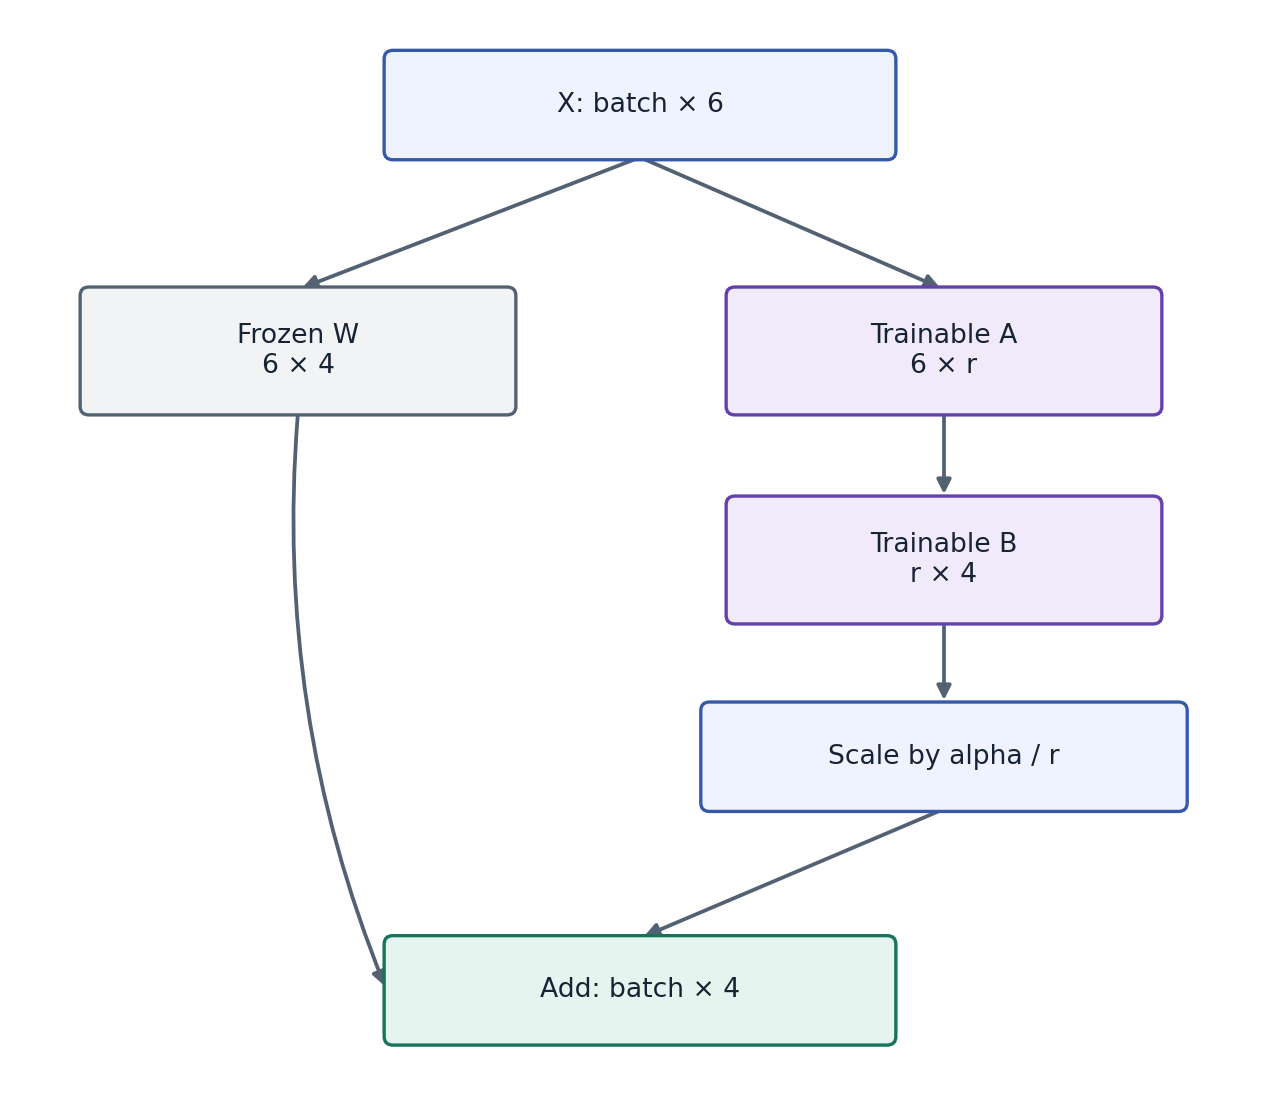

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Input enters both branches. The base weight is frozen; A and B are trainable. Both paths return four features before addition. Include $\alpha/r$ when merging. These are forward-data arrows: gradients update adapter factors but not frozen base parameters.

### Pause and reason

If rank changes while alpha stays fixed, can you omit the scaling when merging?

<details><summary>Compare your reasoning</summary>

No. Merge the exact scaled correction used in forward computation. Otherwise the merged model computes a different function.

</details>

## Before coding: adapt a change, not an entire matrix

Begin with a base mapping that already works on a source task. The new task changes the output in a small number of directions. LoRA represents an added matrix through two smaller factors while preserving the base weights. Freezing the base protects those stored weights; it does not guarantee the adapted outputs retain the old behavior. That is why adaptation and retention need separate evaluation.

Trace dimensions for input width $d$, output width $k$, and rank $r$. The first factor compresses inputs into $r$ coordinates, and the second expands them into the output coordinates. The update matrix can have rank at most $r$, regardless of training time.

## Separate the frozen base from trainable adapters

For input-by-output weights $W_0$, let $A$ have shape $(d,r)$ and $B$ shape $(r,k)$. Compute the base output plus the scaled adapter output. Only the adapter tuple is passed to the gradient function. Keep a copy of $W_0$ and compare it exactly after training.

$$
Y=XW_0+\frac{\alpha}{r}XAB
$$

## Understand initialization and the first gradient

Initialize $A$ randomly and $B$ to zero. The initial adapter output is zero, so predictions match the base. At this first step the gradient with respect to $A$ is zero because it multiplies $B$; the gradient for $B$ can be nonzero. Initializing both factors to zero would block both gradients for this bilinear update.

## Derive the first-step asymmetry

Write the dense-layer output gradient as $G$, with the same batch-by-output shape as the prediction. Let $s=\alpha/r$. The two derivatives below explain initialization. When $B=0$, the first derivative vanishes, while the second can be nonzero if $A$ is random. After one update to $B$, both factors may learn. If both factors start at zero, both gradients vanish and training stalls.

This is a property of the bilinear parameterization, not a JAX bug. Inspect factor norms and individual gradients before changing the learning rate.

$$
\nabla_A L=sX^\top GB^\top,\qquad \nabla_B L=sA^\top X^\top G
$$

## Use rank to predict a failure before training

A rank-one update can represent one independent output-change direction. Consider an ideal update with singular values $3$ and $1$. Any rank-one approximation leaves at least squared Frobenius error $1$; increasing optimization steps cannot remove that rank constraint. This matrix-space statement translates into prediction error only under assumptions about the input distribution. The exercise uses identity inputs so that distinction is visible.

Our main target was constructed as a rank-one update, so near-zero training error is expected. A convincing study compares several ranks on a harder held-out task and reports trainable parameters, optimizer memory, activation memory and measured runtime separately.

## Count the right kind of savings

The fixture has $6\times4=24$ base weights and rank $1$, giving $6+4=10$ trainable adapter scalars. The base remains resident. Real memory includes gradients, optimizer state, activations and runtime buffers. A low-bit frozen base plus adapters also needs a quantization policy and supported kernels; this lab does not implement QLoRA.

## Merge only under an explicit serving contract

Without adapter dropout, an inference merge computes $W_{\mathrm{merged}}=W_0+(\alpha/r)AB$. Check outputs on changed inputs before deleting or replacing anything. Keep the unmerged base, adapter and scaling metadata; a second accidental merge adds the update twice. Packed or quantized bases require dequantization/requantization rules rather than a blind in-place add.

## Save the adaptation identity

An adapter artifact needs the base checkpoint hash, target module names, rank, alpha, dtype and exact factor arrays. Match all of these on load. Compare the adapted task and original task separately; low rank does not prevent forgetting, and this rank-one teacher does not predict the rank required by a real task.

## Make an adapter artifact reproducible

Save the exact base identity, target layer names, tensor orientation, rank, scaling, factor dtype and adapter weights. Reconstruct the unmerged computation before testing a merge. A rank-two adapter with $\alpha=3$ requires scale $1.5$; forgetting that scale may go unnoticed in rank-one examples where it equals one.

Merging is exact algebraically for this dense layer, subject to floating-point rounding. Quantized bases, packed layouts and adapter dropout need additional contracts. Retain original artifacts, compare changed inputs after reload, and reject applying the same update twice. Keep a source-task metric alongside the new task before claiming that adaptation preserved useful behavior.

## 1. Define the frozen-plus-adapter forward pass

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
# Step 1 — 1. Define the frozen-plus-adapter forward pass: The base is an input to the forward pass but is not in the adapter...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `lora_forward(x, base, a, b, ...)` implementing this stage's computation:
def lora_forward(x, base, a, b, alpha=1.0):
    # Evaluate `rank` from the current inputs and state.
    rank = a.shape[1]
    # Return `x @ base + alpha / rank * (x @ a @ b)` to the caller.
    return x @ base + (alpha / rank) * (x @ a @ b)

The base is an input to the forward pass but is not in the adapter tuple differentiated by loss.

## 2. Train a base, freeze it and initialize the adapter

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
# Step 2 — 2. Train a base, freeze it and initialize the adapter: This step includes the source-task training.
x = jnp.asarray(np.random.default_rng(4).normal(size=(24, 6)), jnp.float32)
# Construct and reshape `source_w` into the target tensor dimensions.
source_w = jnp.arange(24, dtype=jnp.float32).reshape(6, 4) / 40
# Initialize array `base` with explicit values and shape.
base = jnp.zeros_like(source_w)
# Differentiate the objective to obtain `base_step` via automatic differentiation.
base_step = jax.jit(jax.grad(lambda w: jnp.mean((x @ w - x @ source_w) ** 2)))
# Repeat the update loop over `range(150)` steps:
for _ in range(150):
    # Evaluate `base` from the current inputs and state.
    base = base - 0.15 * base_step(base)
# Verify contract: `float(jnp.mean((x @ base - x @ source_w) ** 2)) < 0.0001`.
assert float(jnp.mean((x @ base - x @ source_w) ** 2)) < 1e-4
# Convert `frozen` to a host NumPy array for inspection or verification.
frozen = np.asarray(base).copy()
# Initialize array `u` with explicit values and shape.
u = jnp.array([[0.2], [-0.3], [0.1], [0.2], [-0.1], [0.4]])
# Initialize array `v` with explicit values and shape.
v = jnp.array([[0.5, -0.2, 0.3, 0.1]])
# Perform matrix / vector contraction (`@`) to compute `target`.
target = x @ (base + u @ v)
# Initialize explicit deterministic PRNG key `a`.
a = jax.random.normal(jax.random.key(4), (6, 1)) * 0.1
# Allocate initialized array `b` with the specified shape and dtype.
b = jnp.zeros((1, 4))
# Evaluate `params` from the current inputs and state.
params = (a, b)
# Reduce across the target axis to summarize `loss`.
loss = lambda ab: jnp.mean((lora_forward(x, base, *ab, alpha=1.0) - target) ** 2)
# Evaluate both scalar loss and parameter gradients in one pass (`step`).
step = jax.jit(jax.value_and_grad(loss))
# Evaluate `history` from the current inputs and state.
history = []
# Run `step` to compute `initial_grads`.
initial_grads = step(params)[1]
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(initial_grads[0], np.zeros((6, 1)))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert np.linalg.norm(initial_grads[1]) > 0

This step includes the source-task training. Inspect the initial factor gradients: A has zero gradient and B has a nonzero one.

## 3. Adapt and verify the serving merge

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
# Step 3 — 3. Adapt and verify the serving merge: The reference target has rank one by construction.
for _ in range(250):
    # Run `step` to compute `(value, g)`.
    value, g = step(params)
    # Append the current step result to `history`.
    history.append(float(value))
    # Transform every leaf of the parameter PyTree (`params`).
    params = jax.tree.map(lambda a, b: a - 0.4 * b, params, g)

# Evaluate `(a, b)` from the current inputs and state.
a, b = params
# Verify contract: `history[-1] < history[0] * 0.02`.
assert history[-1] < history[0] * 0.02
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(base, frozen)
# Perform matrix contraction / projection to compute `merged`.
merged = base + a @ b
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(x, base, a, b), x @ merged, rtol=1e-5, atol=1e-6
)
# Print the observed values to compare against the expected result.
print(
    'LoRA initial/final:',
    history[0],
    history[-1],
    '; trainable:',
    a.size + b.size,
    'base:',
    base.size,
)

LoRA initial/final: 0.043869297951459885 2.466217665642034e-07 ; trainable: 10 base: 24


The reference target has rank one by construction. Exact base equality and changed-input merge checks answer different questions from adaptation loss.

## Run the example

In [4]:
# Step 1 — 1. Define the frozen-plus-adapter forward pass: The base is an input to the forward pass but is not in the adapter...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `lora_forward(x, base, a, b, ...)` implementing this stage's computation:
def lora_forward(x, base, a, b, alpha=1.0):
    # Evaluate `rank` from the current inputs and state.
    rank = a.shape[1]
    # Return `x @ base + alpha / rank * (x @ a @ b)` to the caller.
    return x @ base + (alpha / rank) * (x @ a @ b)

# Step 2 — 2. Train a base, freeze it and initialize the adapter: This step includes the source-task training.
x = jnp.asarray(np.random.default_rng(4).normal(size=(24, 6)), jnp.float32)
# Construct and reshape `source_w` into the target tensor dimensions.
source_w = jnp.arange(24, dtype=jnp.float32).reshape(6, 4) / 40
# Initialize array `base` with explicit values and shape.
base = jnp.zeros_like(source_w)
# Differentiate the objective to obtain `base_step` via automatic differentiation.
base_step = jax.jit(jax.grad(lambda w: jnp.mean((x @ w - x @ source_w) ** 2)))
# Repeat the update loop over `range(150)` steps:
for _ in range(150):
    # Evaluate `base` from the current inputs and state.
    base = base - 0.15 * base_step(base)
# Verify contract: `float(jnp.mean((x @ base - x @ source_w) ** 2)) < 0.0001`.
assert float(jnp.mean((x @ base - x @ source_w) ** 2)) < 1e-4
# Convert `frozen` to a host NumPy array for inspection or verification.
frozen = np.asarray(base).copy()
# Initialize array `u` with explicit values and shape.
u = jnp.array([[0.2], [-0.3], [0.1], [0.2], [-0.1], [0.4]])
# Initialize array `v` with explicit values and shape.
v = jnp.array([[0.5, -0.2, 0.3, 0.1]])
# Perform matrix / vector contraction (`@`) to compute `target`.
target = x @ (base + u @ v)
# Initialize explicit deterministic PRNG key `a`.
a = jax.random.normal(jax.random.key(4), (6, 1)) * 0.1
# Allocate initialized array `b` with the specified shape and dtype.
b = jnp.zeros((1, 4))
# Evaluate `params` from the current inputs and state.
params = (a, b)
# Reduce across the target axis to summarize `loss`.
loss = lambda ab: jnp.mean((lora_forward(x, base, *ab, alpha=1.0) - target) ** 2)
# Evaluate both scalar loss and parameter gradients in one pass (`step`).
step = jax.jit(jax.value_and_grad(loss))
# Evaluate `history` from the current inputs and state.
history = []
# Run `step` to compute `initial_grads`.
initial_grads = step(params)[1]
# Allocate initialized array `` with the specified shape and dtype.
np.testing.assert_array_equal(initial_grads[0], np.zeros((6, 1)))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert np.linalg.norm(initial_grads[1]) > 0

# Step 3 — 3. Adapt and verify the serving merge: The reference target has rank one by construction.
for _ in range(250):
    # Run `step` to compute `(value, g)`.
    value, g = step(params)
    # Append the current step result to `history`.
    history.append(float(value))
    # Transform every leaf of the parameter PyTree (`params`).
    params = jax.tree.map(lambda a, b: a - 0.4 * b, params, g)

# Evaluate `(a, b)` from the current inputs and state.
a, b = params
# Verify contract: `history[-1] < history[0] * 0.02`.
assert history[-1] < history[0] * 0.02
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(base, frozen)
# Perform matrix contraction / projection to compute `merged`.
merged = base + a @ b
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(x, base, a, b), x @ merged, rtol=1e-5, atol=1e-6
)
# Print the observed values to compare against the expected result.
print(
    'LoRA initial/final:',
    history[0],
    history[-1],
    '; trainable:',
    a.size + b.size,
    'base:',
    base.size,
)

LoRA initial/final: 0.043869297951459885 2.466217665642034e-07 ; trainable: 10 base: 24


Expected: The trained base stays unchanged; 10 adapter scalars fit the rank-one change and merge equivalently.

## LoRA: adapt, save and merge low-rank updates — recorded experiment

Predict: Which initial adapter-gradient bar is zero, and why can training still begin?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: LoRA: adapt, save and merge low-rank updates — recorded experiment
# Evaluate `visual_data` from the current inputs and state.
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'adaptation MSE (squared output units)','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
# Loop over `panel` in `visual_data.get('panels', [visual_data])`:
for panel in visual_data.get('panels',[visual_data]):
    # Evaluate `panel['x']` from the current inputs and state.
    panel['x']=panel['series'][0]['x']

# Evaluate `extra_panel` from the current inputs and state.
extra_panel={'kind':'bar','x':[0,1],'labels':['factor A','factor B'],'series':[{'label':'initial gradient norm','y':[float(jnp.linalg.norm(initial_grads[0])),float(jnp.linalg.norm(initial_grads[1]))]}],'xlabel':'trainable factor','ylabel':'gradient L2 norm','title':'Why the first update changes only B'}
# Evaluate `visual_data` from the current inputs and state.
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}

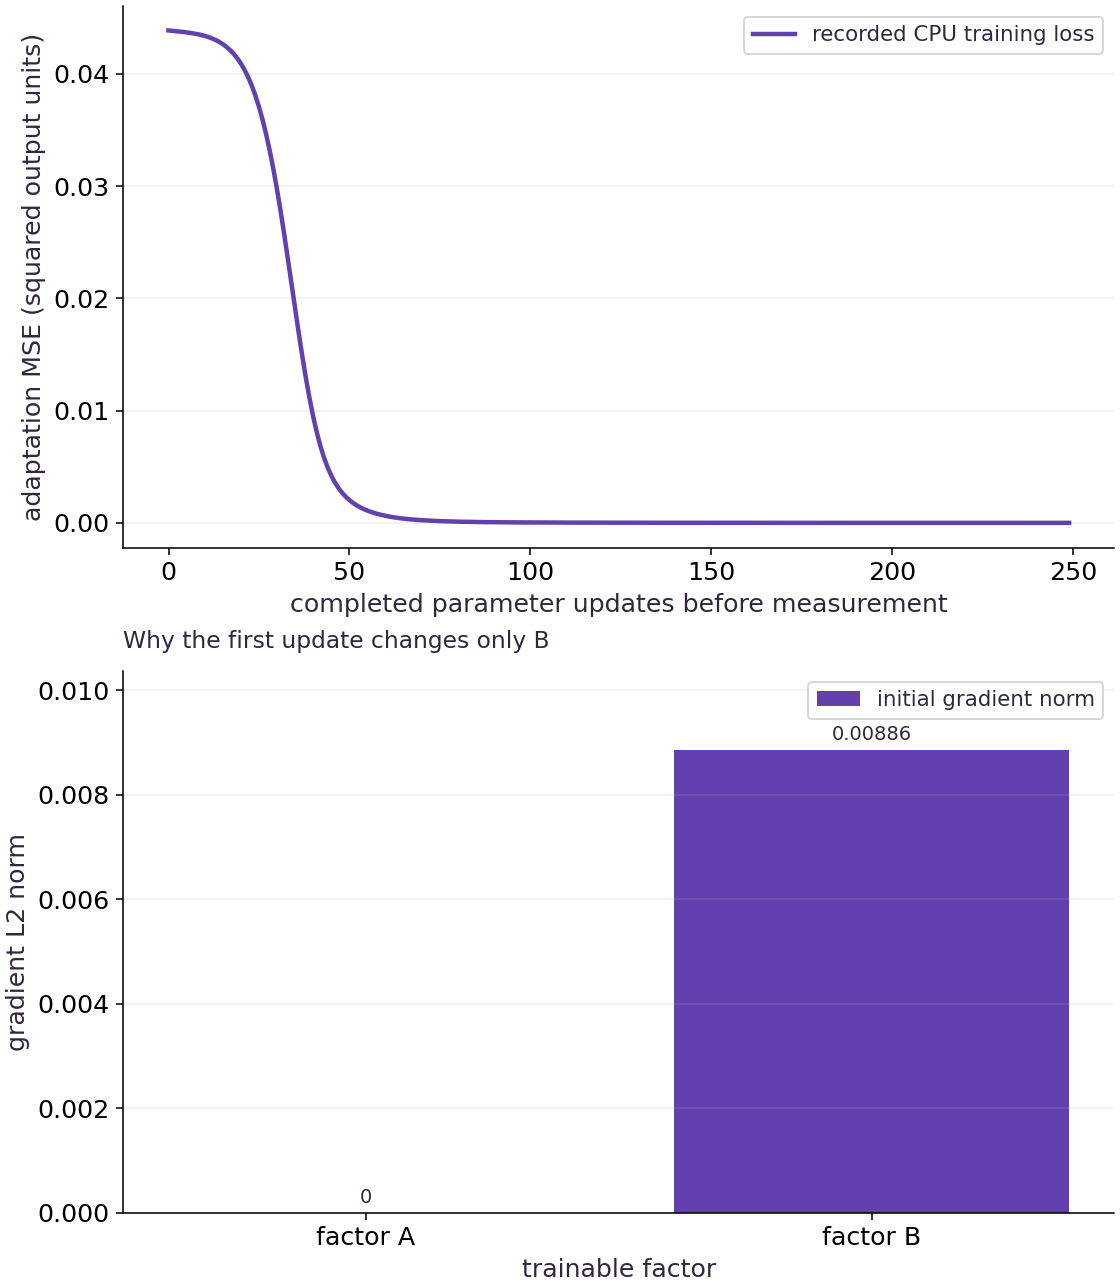

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The plot is adaptation MSE before each update, falling from about $0.044$ to below $10^{-6}$. It does not include the preceding base-training run. The target update was constructed to have rank one, so this is an achievable representation test rather than a universal LoRA performance claim.

The second panel compares the two initial factor-gradient norms. The zero-height A bar is expected because B starts at zero; the positive B bar shows the update has a route to begin learning. After B changes, A can receive gradient. These are initial gradients while the first panel spans the full adaptation run. The all-zero initialization experiment predicts two zero bars and nonzero loss, exposing a stalled parameterization.

### Connect it to the computation

The first adapter update affects B; later updates can train both factors. The unchanged-base assertion, reloaded adapter and new-input merge comparison are separate evidence from the falling training line.

## Show why two zero factors cannot start learning

Predict: If both factors start at zero, can this first-order update move either one?

In [7]:
# Experiment — Show why two zero factors cannot start learning: Each factor’s derivative contains the other factor.
# Initialize array `zero` with explicit values and shape.
zero = (jnp.zeros_like(a), jnp.zeros_like(b))
# Differentiate the objective to obtain `zero_grad` via automatic differentiation.
zero_grad = jax.grad(loss)(zero)
# Verify that the output tensor shape matches our prediction.
assert all(
    np.array_equal(np.asarray(g), np.zeros(g.shape)) for g in zero_grad
)
# Print the observed values to compare against the expected result.
print('Both zero factors produce zero first gradients.')

Both zero factors produce zero first gradients.


Expected: Both factor gradients are exactly zero.

Each factor’s derivative contains the other factor. Randomizing one and zeroing the other preserves the initial base output without blocking the whole update.

## Check both factor gradients with matrix calculus

Predict: At nonzero factors, will the two matrix-gradient formulas agree with autodiff including nonunit alpha?

In [8]:
# Experiment — Check both factor gradients with matrix calculus: Nonzero factors exercise both gradient paths, while nonunit...
rng = np.random.default_rng(14)
# Create device-backed JAX array `a_probe`.
a_probe = jnp.asarray(rng.normal(size=(6, 2)) * 0.1, jnp.float32)
# Create device-backed JAX array `b_probe`.
b_probe = jnp.asarray(rng.normal(size=(2, 4)) * 0.1, jnp.float32)
# Evaluate `scale` from the current inputs and state.
scale = 3.0 / 2
# Evaluate `output_gradient` from the current inputs and state.
output_gradient = (
    2 * (lora_forward(x, base, a_probe, b_probe, 3.0) - target) / target.size
)
# Perform matrix / vector contraction (`@`) to compute `expected_a`.
expected_a = scale * x.T @ output_gradient @ b_probe.T
# Perform matrix / vector contraction (`@`) to compute `expected_b`.
expected_b = scale * a_probe.T @ x.T @ output_gradient
# Differentiate the objective to obtain `(actual_a, actual_b)` via automatic differentiation.
actual_a, actual_b = jax.grad(
    lambda aa, bb: jnp.mean(
        (lora_forward(x, base, aa, bb, 3.0) - target) ** 2
    ),
    argnums=(0, 1),
)(a_probe, b_probe)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(actual_a, expected_a, atol=1e-6)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(actual_b, expected_b, atol=1e-6)
# Print the observed values to compare against the expected result.
print('Both LoRA factor gradients match the matrix-calculus oracle at alpha/r = 1.5.')

Both LoRA factor gradients match the matrix-calculus oracle at alpha/r = 1.5.


Expected: Both factor derivatives match the independent output-gradient calculation.

Nonzero factors exercise both gradient paths, while nonunit scaling catches a factor missing from the derivative. The separate all-zero experiment demonstrates the initialization failure.

## Your exercise

Save both adapter factors and their rank/scaling metadata, reload them and check merged versus unmerged predictions.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Import tempfile for this computation.
2. Create an isolated temporary directory to run and inspect artifacts safely:
3. Read or serialize artifact data on disk (`path`).
4. Convert `` to a host NumPy array for inspection or verification.
5. Enter `np.load(path, allow_pickle=False)` context block:

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Save both adapter factors and their rank/scaling metadata, reload them...
# Import tempfile for this computation.
import tempfile
from pathlib import Path

# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory() as folder:
    # Read or serialize artifact data on disk (`path`).
    path = Path(...)  # TODO: compute path
    # Convert `` to a host NumPy array for inspection or verification.
    np.savez(
        path,
        a = np.asarray(...)  # TODO: compute a
        b = np.asarray(...)  # TODO: compute b
        alpha = np.array(...)  # TODO: compute alpha
        rank = np.array(...)  # TODO: compute rank
    )
    # Enter `np.load(path, allow_pickle=False)` context block:
    with np.load(path, allow_pickle=False) as z:
        # Verify that the output tensor shape matches our prediction.
        assert int(z['rank'])  # TODO: complete assertion check
        # Perform matrix contraction / projection to compute ``.
        np.testing.assert_allclose(
            lora_forward(x, base, z['a'], z['b'], float(z['alpha'])),
            x @ merged,
            atol = ...  # TODO: compute atol
            rtol = ...  # TODO: compute rtol
        )
# Print the observed values to compare against the expected result.
print('Adapter round trip and merge checked.')
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Save both adapter factors and their rank/scaling metadata, reload them...
# Import tempfile for this computation.
# import tempfile
# from pathlib import Path

# Create an isolated temporary directory to run and inspect artifacts safely:
# with tempfile.TemporaryDirectory() as folder:
    # Read or serialize artifact data on disk (`path`).
#     path = Path(...)  # TODO: compute path
    # Convert `` to a host NumPy array for inspection or verification.
#     np.savez(
#         path,
#         a = np.asarray(...)  # TODO: compute a
#         b = np.asarray(...)  # TODO: compute b
#         alpha = np.array(...)  # TODO: compute alpha
#         rank = np.array(...)  # TODO: compute rank
#     )
    # Enter `np.load(path, allow_pickle=False)` context block:
#     with np.load(path, allow_pickle=False) as z:
        # Verify that the output tensor shape matches our prediction.
#         assert int(z['rank'])  # TODO: complete assertion check
        # Perform matrix contraction / projection to compute ``.
#         np.testing.assert_allclose(
#             lora_forward(x, base, z['a'], z['b'], float(z['alpha'])),
#             x @ merged,
#             atol = ...  # TODO: compute atol
#             rtol = ...  # TODO: compute rtol
#         )
# Print the observed values to compare against the expected result.
# print('Adapter round trip and merge checked.')

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Save both adapter factors and their rank/scaling metadata, reload them...
# Import tempfile for this computation.
import tempfile
from pathlib import Path

# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory() as folder:
    # Read or serialize artifact data on disk (`path`).
    path = Path(folder) / 'adapter.npz'
    # Convert `` to a host NumPy array for inspection or verification.
    np.savez(
        path,
        a=np.asarray(a),
        b=np.asarray(b),
        alpha=np.array(1.0),
        rank=np.array(1),
    )
    # Enter `np.load(path, allow_pickle=False)` context block:
    with np.load(path, allow_pickle=False) as z:
        # Verify that the output tensor shape matches our prediction.
        assert int(z['rank']) == z['a'].shape[1]
        # Perform matrix contraction / projection to compute ``.
        np.testing.assert_allclose(
            lora_forward(x, base, z['a'], z['b'], float(z['alpha'])),
            x @ merged,
            atol=1e-6,
            rtol=1e-5,
        )
# Print the observed values to compare against the expected result.
print('Adapter round trip and merge checked.')

Adapter round trip and merge checked.


## Check the merge on new inputs · Transfer

Draw a new input batch and compare the merged layer with the adapter path.

Hint: The equivalence is algebraic, so a new input should still agree.

### How to write: Check the merge on new inputs — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Perform matrix contraction / projection to compute ``.
2. Verify contract: `np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merge...`.
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Check the merge on new inputs (Transfer): The second check detects an operational merge error that...
new_x = jnp.asarray(...)  # TODO: compute new_x
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(new_x, base, a, b), new_x @ merged, atol=1e-6, rtol=1e-5
)
# Verify contract: `np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merge...`.
assert np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merged))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('New-input merge passes; accidental double merge changes outputs.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check the merge on new inputs (Transfer): The second check detects an operational merge error that...
# new_x = jnp.asarray(...)  # TODO: compute new_x
# Perform matrix contraction / projection to compute ``.
# np.testing.assert_allclose(
#     lora_forward(new_x, base, a, b), new_x @ merged, atol=1e-6, rtol=1e-5
# )
# Verify contract: `np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merge...`.
# assert np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merged))  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('New-input merge passes; accidental double merge changes outputs.')

## Reference reasoning

The second check detects an operational merge error that training loss alone would not reveal.

In [12]:
# Check the merge on new inputs (Transfer): The second check detects an operational merge error that...
new_x = jnp.asarray(np.random.default_rng(91).normal(size=(7, 6)), jnp.float32)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(new_x, base, a, b), new_x @ merged, atol=1e-6, rtol=1e-5
)
# Verify contract: `np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merge...`.
assert np.linalg.norm(np.asarray(new_x @ (base + 2 * a @ b) - new_x @ merged)) > 1e-3
# Print the observed values to compare against the expected result.
print('New-input merge passes; accidental double merge changes outputs.')

New-input merge passes; accidental double merge changes outputs.


## Test nonunit scaling and an impossible rank-one target · Challenge

Check merge equivalence at rank two with alpha three. Then use identity inputs and a diagonal target with singular values three and one to calculate the best rank-one residual.

Hint: Use an independent singular-value decomposition for the rank bound, and divide alpha by rank in both serving paths.

### How to write: Test nonunit scaling and an impossible rank-one target — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Create device-backed JAX array `a2`.
2. Create device-backed JAX array `b2`.
3. Perform matrix contraction / projection to compute ``.
4. Run `np.diag` to compute `target_update`.
5. Run `np.linalg.svd` to compute `(u_s, s_s, v_s)`.

**Starter code scaffold (fill in the TODOs):**

```python
# Test nonunit scaling and an impossible rank-one target (Challenge): The residual predicts a capacity limit independently of an...
rng = np.random.default_rng(...)  # TODO: compute rng
# Create device-backed JAX array `a2`.
a2 = jnp.asarray(...)  # TODO: compute a2
# Create device-backed JAX array `b2`.
b2 = jnp.asarray(...)  # TODO: compute b2
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(x, base, a2, b2, alpha = ...  # TODO: compute lora_forward(x, base, a2, b2, alpha
    x @ (base + 1.5 * a2 @ b2),
    rtol = ...  # TODO: compute rtol
    atol = ...  # TODO: compute atol
)
# Run `np.diag` to compute `target_update`.
target_update = np.diag(...)  # TODO: compute target_update
# Run `np.linalg.svd` to compute `(u_s, s_s, v_s)`.
u_s, s_s, v_s = np.linalg.svd(...)  # TODO: compute u_s, s_s, v_s
# Perform matrix / vector contraction (`@`) to compute `rank_one`.
rank_one = ...  # TODO: compute rank_one
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(np.sum((target_update - rank_one) ** 2), 1.0)
# Construct an identity matrix ``.
np.testing.assert_allclose(
    np.mean((np.eye(2) @ target_update - np.eye(2) @ rank_one) ** 2), 0.25
)
# Print the observed values to compare against the expected result.
print('Nonunit scaling passes; best rank-one identity-input MSE is 0.25.')
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Test nonunit scaling and an impossible rank-one target (Challenge): The residual predicts a capacity limit independently of an...
# rng = np.random.default_rng(...)  # TODO: compute rng
# Create device-backed JAX array `a2`.
# a2 = jnp.asarray(...)  # TODO: compute a2
# Create device-backed JAX array `b2`.
# b2 = jnp.asarray(...)  # TODO: compute b2
# Perform matrix contraction / projection to compute ``.
# np.testing.assert_allclose(
#     lora_forward(x, base, a2, b2, alpha = ...  # TODO: compute lora_forward(x, base, a2, b2, alpha
#     x @ (base + 1.5 * a2 @ b2),
#     rtol = ...  # TODO: compute rtol
#     atol = ...  # TODO: compute atol
# )
# Run `np.diag` to compute `target_update`.
# target_update = np.diag(...)  # TODO: compute target_update
# Run `np.linalg.svd` to compute `(u_s, s_s, v_s)`.
# u_s, s_s, v_s = np.linalg.svd(...)  # TODO: compute u_s, s_s, v_s
# Perform matrix / vector contraction (`@`) to compute `rank_one`.
# rank_one = ...  # TODO: compute rank_one
# Reduce across the target axis to summarize ``.
# np.testing.assert_allclose(np.sum((target_update - rank_one) ** 2), 1.0)
# Construct an identity matrix ``.
# np.testing.assert_allclose(
#     np.mean((np.eye(2) @ target_update - np.eye(2) @ rank_one) ** 2), 0.25
# )
# Print the observed values to compare against the expected result.
# print('Nonunit scaling passes; best rank-one identity-input MSE is 0.25.')

## Reference reasoning

The residual predicts a capacity limit independently of an optimizer. The nonunit-alpha case catches a scaling bug that the main rank-one demonstration would miss.

In [14]:
# Test nonunit scaling and an impossible rank-one target (Challenge): The residual predicts a capacity limit independently of an...
rng = np.random.default_rng(8)
# Create device-backed JAX array `a2`.
a2 = jnp.asarray(rng.normal(size=(6, 2)), jnp.float32)
# Create device-backed JAX array `b2`.
b2 = jnp.asarray(rng.normal(size=(2, 4)), jnp.float32)
# Perform matrix contraction / projection to compute ``.
np.testing.assert_allclose(
    lora_forward(x, base, a2, b2, alpha=3.0),
    x @ (base + 1.5 * a2 @ b2),
    rtol=1e-5,
    atol=2e-6,
)
# Run `np.diag` to compute `target_update`.
target_update = np.diag([3.0, 1.0])
# Run `np.linalg.svd` to compute `(u_s, s_s, v_s)`.
u_s, s_s, v_s = np.linalg.svd(target_update)
# Perform matrix / vector contraction (`@`) to compute `rank_one`.
rank_one = (u_s[:, :1] * s_s[:1]) @ v_s[:1]
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(np.sum((target_update - rank_one) ** 2), 1.0)
# Construct an identity matrix ``.
np.testing.assert_allclose(
    np.mean((np.eye(2) @ target_update - np.eye(2) @ rank_one) ** 2), 0.25
)
# Print the observed values to compare against the expected result.
print('Nonunit scaling passes; best rank-one identity-input MSE is 0.25.')

Nonunit scaling passes; best rank-one identity-input MSE is 0.25.


## Checkpoint

Does LoRA require updating the base weights during adapter training?

1. No. The base is frozen; the selected adapter parameters receive updates.
2. Yes, because initializing factor $B=0$ blocks all gradients until the base matrix moves.
3. No, and freezing the base weights guarantees that adapted outputs cannot forget the source task.

## Diagnose

If neither factor moves, inspect initialization. If merged predictions drift, check factor orientation, rank scaling, dropout, base identity and accidental repeated merges.

## Evidence

Keep base-training evidence, unchanged base arrays, adapter factors/rank/alpha, initial-gradient checks and reloaded/new-input merge parity.

## Carry forward

- Initialize one LoRA factor randomly and the other to zero so the initial correction is zero while the zero-initialized factor still receives a nonzero first gradient.
- Preserve the base checkpoint identity, rank $r$, and scale $\alpha/r$ in saved adapter artifacts, and verify merged weights $W_0 + (\alpha/r)AB$ against unmerged inference on new inputs.

## Primary references

- [LoRA](https://arxiv.org/abs/2106.09685)